In [79]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
print("All Libaries loaded")

All Libaries loaded


In [81]:
url = "http://api.worldbank.org/v2/country/all/indicator/FX.OWN.TOTL.ZS?date=2021&format=json&per_page=300"
response = requests.get(url)


In [82]:
print(response.status_code)

200


In [83]:
data = response.json()


In [84]:
print(type(data))

print(len(data))

<class 'list'>
2


In [85]:
print(data[0])


{'page': 1, 'pages': 1, 'per_page': 300, 'total': 266, 'sourceid': '2', 'lastupdated': '2026-04-08'}


In [86]:
print(data[1][0])

{'indicator': {'id': 'FX.OWN.TOTL.ZS', 'value': 'Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2021', 'value': None, 'unit': '', 'obs_status': '', 'decimal': 2}


In [87]:
records  = data[1]
real_data = [entry for entry in records if entry['value'] is not None]
print(f"Total entries: {len(records)}")
print(f"Entries with actual data: {len(real_data)}")

Total entries: 266
Entries with actual data: 144


In [88]:
df_wb = pd.DataFrame([
    {
        'country': entry['country']['value'],
        'country_code': entry['countryiso3code'],
        'year': entry['date'],
        'account_ownership': entry['value']
        }
    for entry in real_data

]
)
print(df_wb.head())

                                       country country_code  year  \
0                                   Arab World          ARB  2021   
1                          East Asia & Pacific          EAS  2021   
2  East Asia & Pacific (excluding high income)          EAP  2021   
3                                    Euro area          EMU  2021   
4                        Europe & Central Asia          ECS  2021   

   account_ownership  
0          40.210000  
1          82.850000  
2          79.701061  
3          98.510000  
4          89.570000  


In [89]:
df_wb.describe()

,account_ownership
count,144.000000
mean,70.205597
std,24.602815
min,5.831407
25%,49.577413
50%,73.425181
75%,94.897254
max,100.000000


In [90]:
df_wb.sort_values('account_ownership').head(10)


,country,country_code,year,account_ownership
122,South Sudan,SSD,2021,5.831407
22,Afghanistan,AFG,2021,9.653822
70,Iraq,IRQ,2021,18.565282
84,Lebanon,LBN,2021,20.703098
105,Pakistan,PAK,2021,20.980631
101,Nicaragua,NIC,2021,26.032803
52,"Egypt, Arab Rep.",EGY,2021,27.444006
117,Sierra Leone,SLE,2021,28.846604
62,Guinea,GIN,2021,30.440336
37,Cambodia,KHM,2021,33.394992


In [91]:
df_wb.sort_values('account_ownership', ascending=False).head(5)



,country,country_code,year,account_ownership
49,Denmark,DNK,2021,100.000000
66,Iceland,ISL,2021,100.000000
59,Germany,DEU,2021,99.976594
28,Austria,AUT,2021,99.950717
136,United Kingdom,GBR,2021,99.763274


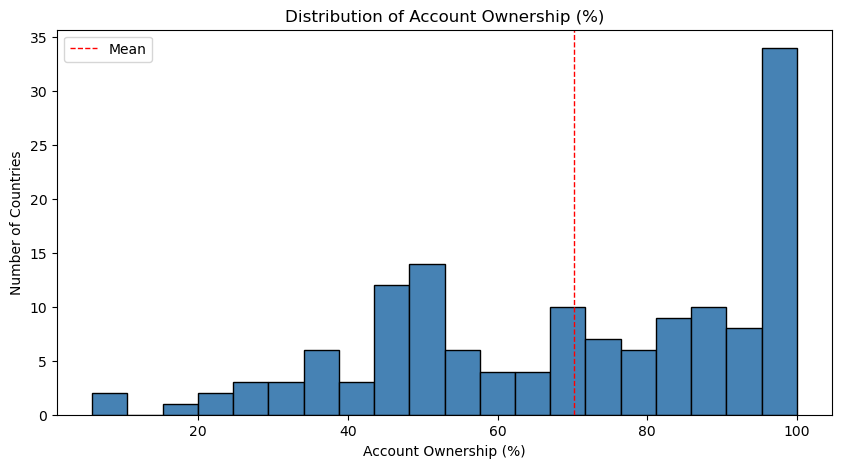

In [92]:
plt.figure(figsize=(10, 5))
plt.hist(df_wb['account_ownership'], bins=20, edgecolor='black',color='steelblue')
plt.title('Distribution of Account Ownership (%)')
plt.xlabel('Account Ownership (%)')
plt.ylabel('Number of Countries')
plt.axvline(df_wb['account_ownership'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.legend()
plt.show()



In [93]:
print(df_wb[df_wb['account_ownership'] > 95].shape)

(34, 4)


## GDP Per Capita

In [94]:
url_GDP_PC = "http://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?date=2021&format=json&per_page=300"
response_gdp_pc = requests.get(url_GDP_PC)


In [95]:
print(response_gdp_pc.status_code)
data_gdp_pc = response_gdp_pc.json()

200


In [96]:
print(type(data_gdp_pc))
print(len(data_gdp_pc))

<class 'list'>
2


In [97]:
print(data_gdp_pc[1])

[{'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2021', 'value': 1562.41617477738, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ZI', 'value': 'Africa Western and Central'}, 'countryiso3code': 'AFW', 'date': '2021', 'value': 2112.79407637079, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': '1A', 'value': 'Arab World'}, 'countryiso3code': 'ARB', 'date': '2021', 'value': 6697.41498492196, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'S3', 'value': 'Caribbean small states'}, 'countryiso3code': 'CSS', 'date': '2021', 'value': 13995.2694921728, 'unit': '', 'obs_status': '

In [98]:
records_gdp_pc  = data_gdp_pc[1]
real_data_gdp_pc = [entry for entry in records_gdp_pc if entry['value'] is not None]
print(f"Total Entries for GDP  per Capita : {len(records_gdp_pc)}")
print(f"Entries with Actual data: {len(real_data_gdp_pc)}")

Total Entries for GDP  per Capita : 266
Entries with Actual data: 258


In [99]:
df_gdp_pc = pd.DataFrame([
    {
        'country': entry['country']['value'],
        'country_code' : entry['countryiso3code'],
        'year': entry['date'],
        'gdp_per_capita': entry['value']
    }
    for entry in real_data_gdp_pc
])

In [100]:
print(df_gdp_pc.head())

                          country country_code  year  gdp_per_capita
0     Africa Eastern and Southern          AFE  2021     1562.416175
1      Africa Western and Central          AFW  2021     2112.794076
2                      Arab World          ARB  2021     6697.414985
3          Caribbean small states          CSS  2021    13995.269492
4  Central Europe and the Baltics          CEB  2021    19223.927403


In [101]:
df_gdp_pc.describe()

,gdp_per_capita
count,258.000000
mean,18803.437185
std,28779.971299
min,264.980379
25%,2462.698252
50%,7001.419123
75%,22009.595072
max,223823.363960


In [102]:
df_gdp_pc.sort_values('gdp_per_capita').head(10)

,country,country_code,year,gdp_per_capita
78,Burundi,BDI,2021,264.980379
48,Afghanistan,AFG,2021,356.496214
161,Madagascar,MDG,2021,483.469463
84,Central African Republic,CAF,2021,492.263143
177,Mozambique,MOZ,2021,509.907829
219,"Somalia, Fed. Rep.",SOM,2021,549.056995
91,"Congo, Dem. Rep.",COD,2021,595.743074
186,Niger,NER,2021,608.722440
162,Malawi,MWI,2021,617.446994
28,Low income,,2021,651.812638


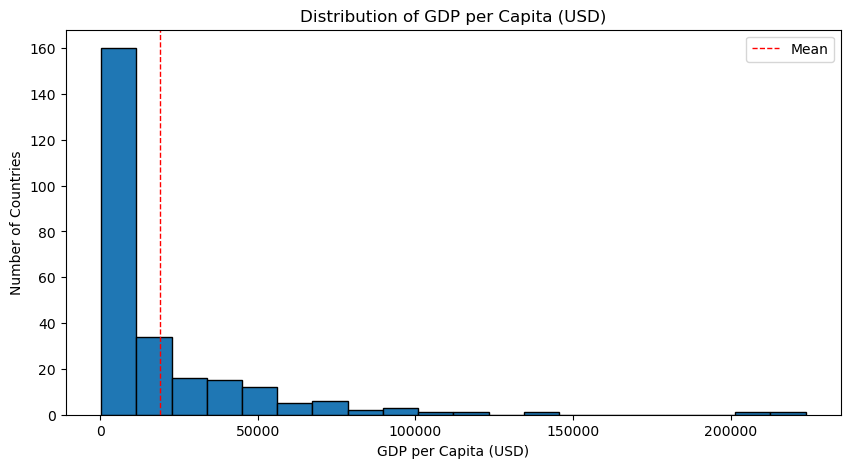

In [103]:
plt.figure(figsize=(10, 5))
plt.hist(df_gdp_pc['gdp_per_capita'], bins=20, edgecolor='black')
plt.title('Distribution of GDP per Capita (USD)')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Number of Countries')
plt.axvline(df_gdp_pc['gdp_per_capita'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.legend()
plt.show()
